# 2. GET THE MODEL

In [2]:
import pandas as pd

dataset = pd.read_csv('../../datasets/student_perf.csv')

# 3. EDA AND PREPROCESSING

In [3]:
dataset.shape

(10000, 6)

In [4]:
dataset.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [5]:
dataset.isnull().sum()

Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64

In [6]:
dataset.drop_duplicates(inplace= True)
dataset.duplicated().sum()


np.int64(0)

In [7]:
dataset.dtypes

Hours Studied                         int64
Previous Scores                       int64
Extracurricular Activities           object
Sleep Hours                           int64
Sample Question Papers Practiced      int64
Performance Index                   float64
dtype: object

In [8]:
column_object = ['Extracurricular Activities']
dataset = pd.get_dummies(dataset, columns= column_object, drop_first = True, dtype= int)
dataset.head()

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index,Extracurricular Activities_Yes
0,7,99,9,1,91.0,1
1,4,82,4,2,65.0,0
2,8,51,7,2,45.0,1
3,5,52,5,2,36.0,1
4,7,75,8,5,66.0,0


In [9]:
dataset.skew()

Hours Studied                      -0.003348
Previous Scores                     0.005581
Sleep Hours                        -0.041350
Sample Question Papers Practiced   -0.034893
Performance Index                  -0.000412
Extracurricular Activities_Yes      0.020059
dtype: float64

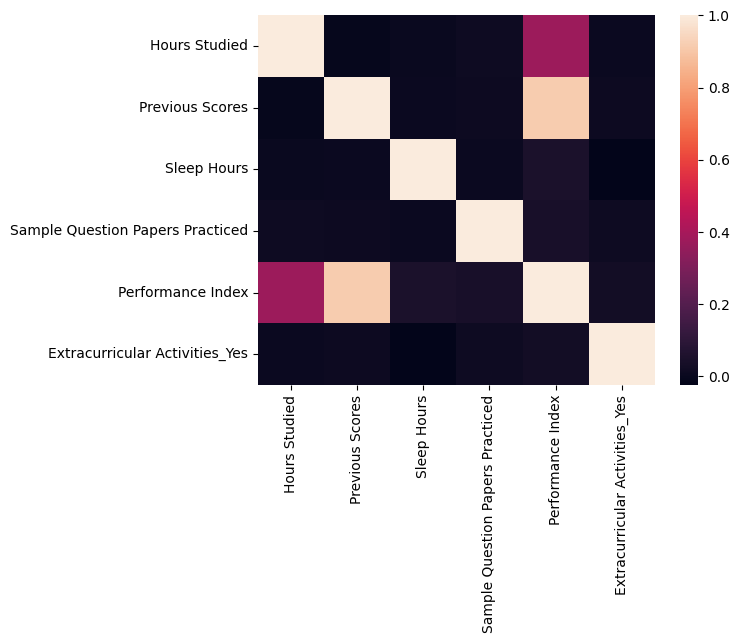

In [10]:
correlation = dataset.corr()
import seaborn as sns

sns.heatmap(correlation);

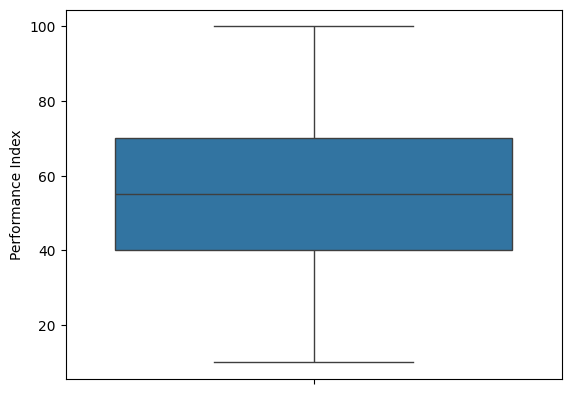

In [11]:
sns.boxplot(dataset['Performance Index']);

In [12]:
dataset.describe()

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index,Extracurricular Activities_Yes
count,9873.000000,9873.000000,9873.000000,9873.000000,9873.000000,9873.000000
mean,4.992100,69.441102,6.531652,4.583004,55.216651,0.494986
std,2.589081,17.325601,1.697683,2.867202,19.208570,0.500000
min,1.000000,40.000000,4.000000,0.000000,10.000000,0.000000
25%,3.000000,54.000000,5.000000,2.000000,40.000000,0.000000
50%,5.000000,69.000000,7.000000,5.000000,55.000000,0.000000
75%,7.000000,85.000000,8.000000,7.000000,70.000000,1.000000
max,9.000000,99.000000,9.000000,9.000000,100.000000,1.000000


# 4. SPLIT

In [13]:
X = dataset.drop(columns=['Performance Index'])
X.head()

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Extracurricular Activities_Yes
0,7,99,9,1,1
1,4,82,4,2,0
2,8,51,7,2,1
3,5,52,5,2,1
4,7,75,8,5,0


In [14]:
y = dataset[['Performance Index']]
y.head()

,Performance Index
0,91.0
1,65.0
2,45.0
3,36.0
4,66.0


In [15]:
from sklearn.model_selection import train_test_split

X_train, x_test, Y_train, y_test = train_test_split(X, y, test_size= 0.3, random_state= 73)


# 5. PREPROCESSING 2, MODEL SELECT AND ACCURACY

In [16]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("Model", LinearRegression())
])

pipe.fit(X_train, Y_train)


y_preds_train = pipe.predict(X_train)
r2_train = r2_score(Y_train, y_preds_train)
print(f"The accuracy of train part r2 was: {r2_train*100:.2f}")


# PREDICT AND ACCURACY OF THE TEST PART
y_preds_test = pipe.predict(x_test)
r2_test = r2_score(y_test, y_preds_test)
print(f"The accuracy of test part r2 was: {r2_test*100:.2f}")


The accuracy of train part r2 was: 98.86
The accuracy of test part r2 was: 98.89
